In [3]:
!git clone https://github.com/shahnabin61-cyber/nepse-lstm-forecast.git
%cd nepse-lstm-forecast
!pip install -r requirements.txt

!git clone https://github.com/Aabishkar2/nepse-data.git


Cloning into 'nepse-lstm-forecast'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 7 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.
/content/nepse-lstm-forecast/nepse-lstm-forecast
Cloning into 'nepse-data'...
remote: Enumerating objects: 126516, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 126516 (delta 48), reused 45 (delta 45), pack-reused 126415 (from 2)
Receiving objects: 100% (126516/126516), 36.32 MiB | 19.32 MiB/s, done.
Resolving deltas: 100% (122723/122723), done.


In [5]:
!pwd
!ls


/content/nepse-lstm-forecast/nepse-lstm-forecast
nepse-data  notebooks  README.md  requirements.txt  src


In [6]:
import pandas as pd

df = pd.read_csv('nepse-data/data/company-wise/NABIL.csv')
print(df.shape)
print(df.columns.tolist())
df.head()


(3503, 9)
['published_date', 'open', 'high', 'low', 'close', 'per_change', 'traded_quantity', 'traded_amount', 'status']


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2011-05-15,1091.0,1155.0,1112.0,1155.0,NaN,38.0,43057.0,0
1,2011-05-16,1155.0,1193.0,1160.0,1193.0,3.29,156.0,183026.0,0
2,2011-05-18,1193.0,1172.0,1150.0,1172.0,-1.76,939.0,1087972.0,0
3,2011-05-19,1172.0,1194.0,1155.0,1194.0,1.88,490.0,573992.0,0
4,2011-05-22,1194.0,1193.0,1178.0,1178.0,-1.34,115.0,135930.0,0


In [7]:
# check date range and gaps
df['published_date'] = pd.to_datetime(df['published_date'])
print(df['published_date'].min(), df['published_date'].max())

# check for missing values
print(df.isnull().sum())

# check the 'status' column - what values does it take?
print(df['status'].value_counts())

# make sure it's sorted by date ascending
print(df['published_date'].is_monotonic_increasing)

2011-05-15 00:00:00 2026-09-03 00:00:00
published_date     0
open               0
high               0
low                0
close              0
per_change         1
traded_quantity    0
traded_amount      0
status             0
dtype: int64
status
 0    1636
-1    1191
 1     676
Name: count, dtype: int64
False


In [8]:
df = df.sort_values('published_date').reset_index(drop=True)
print(df['published_date'].is_monotonic_increasing)

True


In [9]:
#BUILD THE SEQUENCES
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# use just the close price for now
data = df[['close']].values  # shape (n, 1)

# chronological split - 70% train, 15% val, 15% test
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(train_data.shape, val_data.shape, test_data.shape)

# scale - fit ONLY on training data to avoid leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# sliding window sequence builder
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val, y_val = create_sequences(val_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

(2452, 1) (525, 1) (526, 1)
Train: (2392, 60, 1) (2392, 1)
Val: (465, 60, 1) (465, 1)
Test: (466, 60, 1) (466, 1)


In [10]:
#Custom Dataset + DataLoader:
import torch
from torch.utils.data import Dataset, DataLoader

class NepseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = NepseDataset(X_train, y_train)
val_dataset = NepseDataset(X_val, y_val)
test_dataset = NepseDataset(X_test, y_test)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# sanity check
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([32, 60, 1]) torch.Size([32, 1])


In [11]:
# LSTM model:
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        # take the output from the last timestep
        last_out = out[:, -1, :]
        return self.fc(last_out)

model = LSTMForecaster()
print(model)

# sanity check with a batch
out = model(xb)
print(out.shape)  # should be (batch_size, 1)

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
torch.Size([32, 1])


In [12]:
# MANUAL TRAINING LOOP
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = LSTMForecaster().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # --- training ---
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # --- validation ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_val_loss += loss.item() * xb.size(0)

    avg_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")

Using device: cpu
Epoch 5/50 - Train Loss: 0.001377 - Val Loss: 0.000241
Epoch 10/50 - Train Loss: 0.000913 - Val Loss: 0.000171
Epoch 15/50 - Train Loss: 0.000741 - Val Loss: 0.000153
Epoch 20/50 - Train Loss: 0.000630 - Val Loss: 0.000170
Epoch 25/50 - Train Loss: 0.000492 - Val Loss: 0.000224
Epoch 30/50 - Train Loss: 0.000424 - Val Loss: 0.000329
Epoch 35/50 - Train Loss: 0.000462 - Val Loss: 0.000042
Epoch 40/50 - Train Loss: 0.000385 - Val Loss: 0.000040
Epoch 45/50 - Train Loss: 0.000383 - Val Loss: 0.000055
Epoch 50/50 - Train Loss: 0.000371 - Val Loss: 0.000050


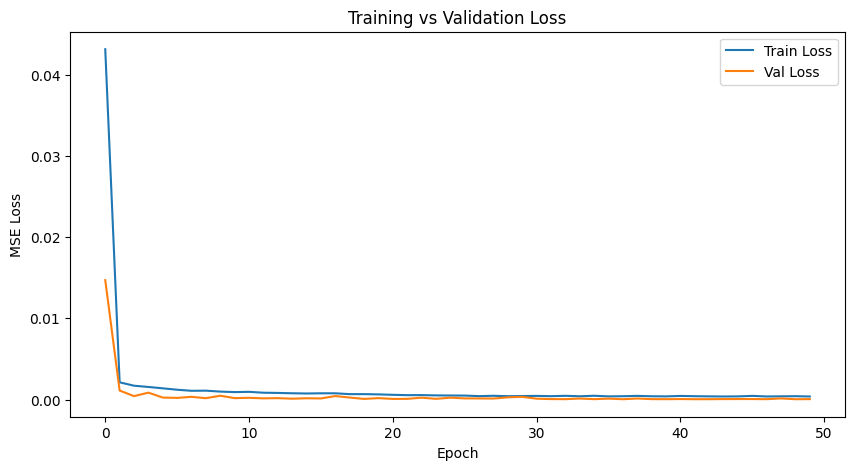

In [13]:
#Plot train vs val loss:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Test RMSE: 7.73
Test MAE: 5.70


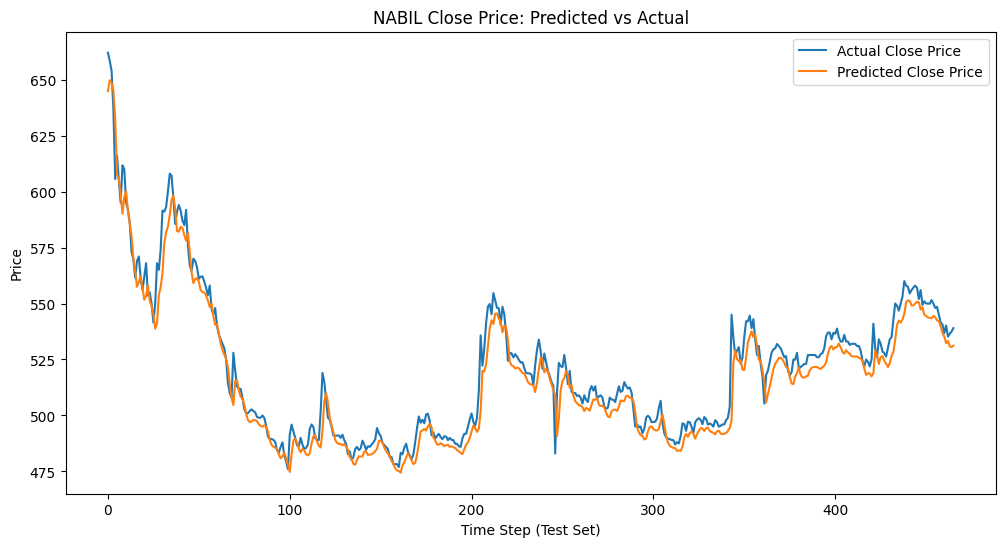

In [14]:
#Evaluate on test set + get predictions in real price scale:

model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        predictions.append(preds.cpu().numpy())
        actuals.append(yb.numpy())

predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# inverse scale back to real prices
predictions_real = scaler.inverse_transform(predictions)
actuals_real = scaler.inverse_transform(actuals)

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(actuals_real, predictions_real))
mae = mean_absolute_error(actuals_real, predictions_real)
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")

# plot predicted vs actual
plt.figure(figsize=(12, 6))
plt.plot(actuals_real, label='Actual Close Price')
plt.plot(predictions_real, label='Predicted Close Price')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Price')
plt.title('NABIL Close Price: Predicted vs Actual')
plt.legend()
plt.show()

In [15]:
#Naive baseline + RMSE/MAE (run this first, you'll get your missing metrics too):
from sklearn.metrics import mean_squared_error, mean_absolute_error

# LSTM metrics (in case you didn't capture them earlier)
lstm_rmse = np.sqrt(mean_squared_error(actuals_real, predictions_real))
lstm_mae = mean_absolute_error(actuals_real, predictions_real)

# naive baseline: predict tomorrow = today's actual close
naive_preds = actuals_real[:-1]
naive_actuals = actuals_real[1:]

naive_rmse = np.sqrt(mean_squared_error(naive_actuals, naive_preds))
naive_mae = mean_absolute_error(naive_actuals, naive_preds)

print(f"LSTM  - RMSE: {lstm_rmse:.2f}, MAE: {lstm_mae:.2f}")
print(f"Naive - RMSE: {naive_rmse:.2f}, MAE: {naive_mae:.2f}")

LSTM  - RMSE: 7.73, MAE: 5.70
Naive - RMSE: 5.87, MAE: 3.70


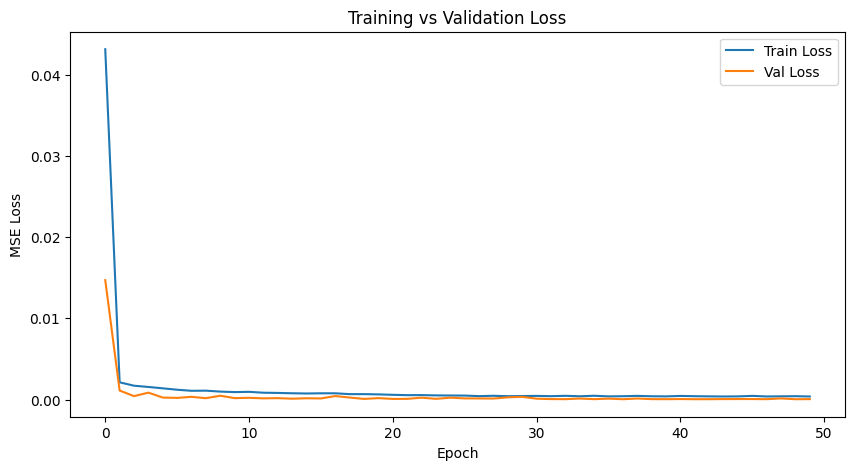

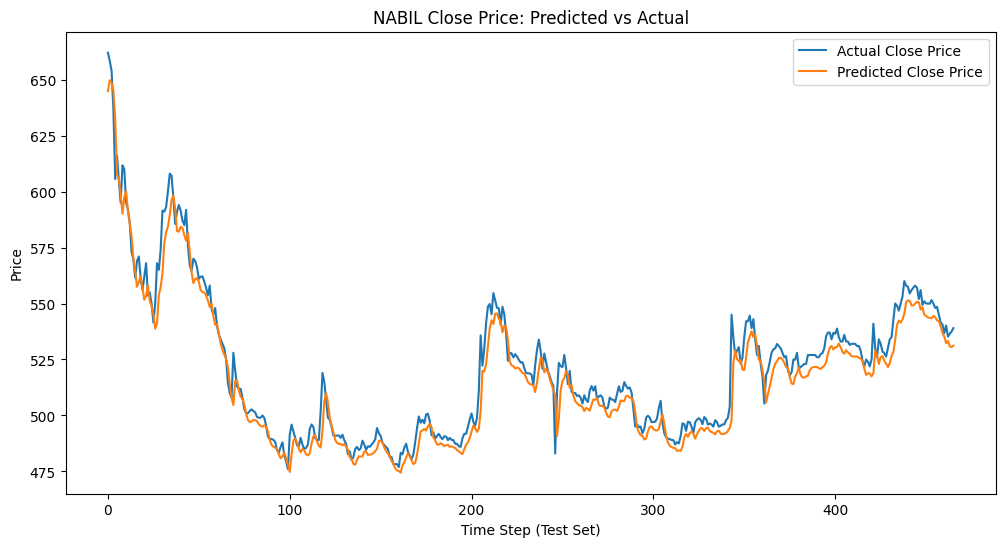

In [16]:
#Save trained model and the loss/prediction plots:

import os
os.makedirs('outputs', exist_ok=True)

torch.save(model.state_dict(), 'outputs/lstm_model.pth')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('Training vs Validation Loss'); plt.legend()
plt.savefig('outputs/loss_curve.png')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(actuals_real, label='Actual Close Price')
plt.plot(predictions_real, label='Predicted Close Price')
plt.xlabel('Time Step (Test Set)'); plt.ylabel('Price'); plt.title('NABIL Close Price: Predicted vs Actual'); plt.legend()
plt.savefig('outputs/predicted_vs_actual.png')
plt.show()

Let's try the return-prediction fix. We need to rebuild the target as percent change instead of raw price — this changes what the model is learning, not the whole pipeline.

In [17]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# calculate percent change (return) instead of using raw close
df['return'] = df['close'].pct_change()
df_returns = df.dropna(subset=['return']).reset_index(drop=True)

data = df_returns[['return']].values

n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

# StandardScaler fits better than MinMax for returns (centered around 0)
scaler_r = StandardScaler()
train_scaled = scaler_r.fit_transform(train_data)
val_scaled = scaler_r.transform(val_data)
test_scaled = scaler_r.transform(test_data)

WINDOW_SIZE = 60

X_train_r, y_train_r = create_sequences(train_scaled, WINDOW_SIZE)
X_val_r, y_val_r = create_sequences(val_scaled, WINDOW_SIZE)
X_test_r, y_test_r = create_sequences(test_scaled, WINDOW_SIZE)

print(X_train_r.shape, y_train_r.shape)

(2391, 60, 1) (2391, 1)


In [18]:
# rebuild the datasets/loaders and train a fresh model (same architecture, new data)

train_dataset_r = NepseDataset(X_train_r, y_train_r)
val_dataset_r = NepseDataset(X_val_r, y_val_r)
test_dataset_r = NepseDataset(X_test_r, y_test_r)

train_loader_r = DataLoader(train_dataset_r, batch_size=32, shuffle=True)
val_loader_r = DataLoader(val_dataset_r, batch_size=32, shuffle=False)
test_loader_r = DataLoader(test_dataset_r, batch_size=32, shuffle=False)

model_r = LSTMForecaster().to(device)
optimizer_r = optim.Adam(model_r.parameters(), lr=0.001)

EPOCHS = 50
train_losses_r, val_losses_r = [], []

for epoch in range(EPOCHS):
    model_r.train()
    total_train_loss = 0
    for xb, yb in train_loader_r:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_r.zero_grad()
        preds = model_r(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer_r.step()
        total_train_loss += loss.item() * xb.size(0)
    train_losses_r.append(total_train_loss / len(train_dataset_r))

    model_r.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader_r:
            xb, yb = xb.to(device), yb.to(device)
            preds = model_r(xb)
            loss = criterion(preds, yb)
            total_val_loss += loss.item() * xb.size(0)
    val_losses_r.append(total_val_loss / len(val_dataset_r))

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_losses_r[-1]:.6f} - Val Loss: {val_losses_r[-1]:.6f}")

Epoch 5/50 - Train Loss: 0.902650 - Val Loss: 0.378779
Epoch 10/50 - Train Loss: 0.891734 - Val Loss: 0.389551
Epoch 15/50 - Train Loss: 0.875182 - Val Loss: 0.398152
Epoch 20/50 - Train Loss: 0.837582 - Val Loss: 0.409341
Epoch 25/50 - Train Loss: 0.808659 - Val Loss: 0.403499
Epoch 30/50 - Train Loss: 0.760276 - Val Loss: 0.408600
Epoch 35/50 - Train Loss: 0.722733 - Val Loss: 0.417134
Epoch 40/50 - Train Loss: 0.683620 - Val Loss: 0.429864
Epoch 45/50 - Train Loss: 0.678913 - Val Loss: 0.439749
Epoch 50/50 - Train Loss: 0.621656 - Val Loss: 0.466832


In [19]:
model_r.eval()
preds_r, actuals_r = [], []

with torch.no_grad():
    for xb, yb in test_loader_r:
        xb = xb.to(device)
        preds = model_r(xb)
        preds_r.append(preds.cpu().numpy())
        actuals_r.append(yb.numpy())

preds_r = np.concatenate(preds_r)
actuals_r = np.concatenate(actuals_r)

# directional accuracy: did we get the sign right?
pred_direction = (preds_r > 0).astype(int)
actual_direction = (actuals_r > 0).astype(int)
directional_accuracy = (pred_direction == actual_direction).mean()

print(f"Directional Accuracy: {directional_accuracy:.2%}")
print(f"(50% = coin flip baseline)")

Directional Accuracy: 49.14%
(50% = coin flip baseline)
